epoch: 0 loss: 1867204477.8468
epoch: 50 loss: 250579286.1448
epoch: 100 loss: 36227794.1133
epoch: 150 loss: 6871483.6338
epoch: 200 loss: 2613090.9785
epoch: 250 loss: 1921320.3219
epoch: 300 loss: 1786124.4523
epoch: 350 loss: 1753366.5677

Train MSE: 1743964.040667152
Test MSE: 742030.4094043642
R2 Score: 0.9396665302182484


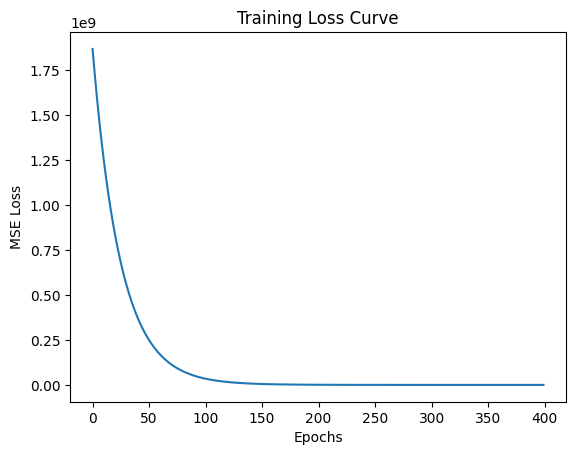

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

np.random.seed(0)

data = pd.read_csv("multiple_linear_regression_dataset.csv")

X = data.iloc[:,:-1].values
y = data.iloc[:,-1].values.reshape(-1,1)

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_samples,n_features = X_train.shape

W = np.random.randn(n_features,1)*0.01
b = 0

lr = 0.01
epochs = 400

loss_history = []

for epoch in range(epochs):

    y_pred = np.dot(X_train,W) + b

    error = y_pred - y_train
    loss = np.mean(error**2)
    loss_history.append(loss)

    dW = (2/n_samples) * np.dot(X_train.T,error)
    db = (2/n_samples) * np.sum(error)

    W -= lr * dW
    b -= lr * db

    if epoch % 50 == 0:
        print("epoch:",epoch,"loss:",round(loss,4))

train_pred = np.dot(X_train,W) + b
test_pred = np.dot(X_test,W) + b

print("\nTrain MSE:",mean_squared_error(y_train,train_pred))
print("Test MSE:",mean_squared_error(y_test,test_pred))

print("R2 Score:",r2_score(y_test,test_pred))

plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.show()